# Market Basket Analysis — Online Retail II
Association rule mining (Apriori algorithm) to find products that are frequently bought together, using the `online_retail_II.xlsx` transactional dataset.

In [1]:
!pip install mlxtend -q  # install mlxtend (Apriori + association_rules live here)

error: externally-managed-environment

× This environment is externally managed
╰─> To install Python packages system-wide, try apt install
    python3-xyz, where xyz is the package you are trying to
    install.
    
    If you wish to install a non-Debian-packaged Python package,
    create a virtual environment using python3 -m venv path/to/venv.
    Then use path/to/venv/bin/python and path/to/venv/bin/pip. Make
    sure you have python3-full installed.
    
    If you wish to install a non-Debian packaged Python application,
    it may be easiest to use pipx install xyz, which will manage a
    virtual environment for you. Make sure you have pipx installed.
    
    See /usr/share/doc/python3.12/README.venv for more information.

note: If you believe this is a mistake, please contact your Python installation or OS distribution provider. You can override this, at the risk of breaking your Python installation or OS, by passing --break-system-packages.
hint: See PEP 668 for the detai

In [2]:
import numpy as np                                    # numeric operations
import pandas as pd                                   # data loading and manipulation
from mlxtend.preprocessing import TransactionEncoder    # turns lists of items into a 0/1 matrix (memory-efficient/sparse)
from mlxtend.frequent_patterns import apriori          # mines frequent itemsets
from mlxtend.frequent_patterns import association_rules  # turns itemsets into rules
import matplotlib.pyplot as plt                       # plotting the results


## 1. Load the data
The file has two sheets (2009-2010 and 2010-2011); we load and stack both.

In [3]:
xl = pd.ExcelFile('online_retail_II.xlsx')            # open the Excel file
print(xl.sheet_names)                                 # show the sheet names


['Year 2009-2010', 'Year 2010-2011']


In [4]:
df_2009 = xl.parse('Year 2009-2010')                  # load first sheet
df_2010 = xl.parse('Year 2010-2011')                  # load second sheet
df = pd.concat([df_2009, df_2010], ignore_index=True)  # stack both years into one dataframe
del df_2009, df_2010                                  # free the individual sheets, we only need the combined df
df.shape                                              # check total rows/columns


(1067371, 8)

In [5]:
df.head()  # peek at the first few rows

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


In [6]:
df.info()  # check dtypes and missing values

<class 'pandas.DataFrame'>
RangeIndex: 1067371 entries, 0 to 1067370
Data columns (total 8 columns):
 #   Column       Non-Null Count    Dtype         
---  ------       --------------    -----         
 0   Invoice      1067371 non-null  object        
 1   StockCode    1067371 non-null  object        
 2   Description  1062989 non-null  object        
 3   Quantity     1067371 non-null  int64         
 4   InvoiceDate  1067371 non-null  datetime64[us]
 5   Price        1067371 non-null  float64       
 6   Customer ID  824364 non-null   float64       
 7   Country      1067371 non-null  str           
dtypes: datetime64[us](1), float64(2), int64(1), object(3), str(1)
memory usage: 65.1+ MB


## 2. Clean the data
- Strip whitespace from product descriptions
- Drop rows with no `Invoice` or `Customer ID`
- Remove cancelled orders (Invoice codes starting with 'C')
- Keep only positive quantities and prices

In [7]:
df['Description'] = df['Description'].str.strip()          # remove leading/trailing spaces in product names
df.dropna(axis=0, subset=['Invoice', 'Customer ID'], inplace=True)  # drop rows missing invoice or customer id
df['Invoice'] = df['Invoice'].astype('str')                 # cast invoice to string so we can filter text
df = df[~df['Invoice'].str.contains('C')]                   # remove cancelled invoices (they start with 'C')
df = df[df['Quantity'] > 0]                                 # keep only positive quantities (real purchases)
df = df[df['Price'] > 0]                                    # keep only positive prices (drop free/adjustment rows)
df.shape                                                     # check size after cleaning


(805549, 8)

In [8]:
df['Country'].value_counts().head(10)  # see which countries have the most transactions

Country
United Kingdom    725250
Germany            16694
EIRE               15743
France             13812
Netherlands         5088
Spain               3719
Belgium             3068
Switzerland         3011
Portugal            2446
Australia           1812
Name: count, dtype: int64

## 3. Build the "basket" matrix
Apriori needs one row per invoice (transaction) and one column per product, with 1/0 showing whether that product was in the invoice.

A plain pivot table (`unstack`) builds a dense matrix, which for the ~700k-row UK data explodes to gigabytes of RAM. Instead we use mlxtend's `TransactionEncoder` with `sparse=True`, which only stores the 1s — this keeps memory small even for tens of thousands of invoices.

In [9]:
def build_basket(data, country):                                  # helper: build a memory-efficient 0/1 invoice x product matrix
    subset = data[data['Country'] == country]                        # keep only rows for this country
    transactions = subset.groupby('Invoice')['Description'].apply(list).tolist()  # list of products per invoice
    te = TransactionEncoder()                                        # encoder that learns the product vocabulary
    te_array = te.fit(transactions).transform(transactions, sparse=True)  # transform to a sparse 0/1 matrix
    return pd.DataFrame.sparse.from_spmatrix(te_array, columns=te.columns_)  # wrap as a sparse pandas DataFrame


In [10]:
basket_fr = build_basket(df, 'France')  # build the France basket matrix
basket_fr.shape                         # (num invoices, num unique products)


(614, 2177)

## 4. Mine frequent itemsets and rules (France)

In [11]:
frequent_itemsets_fr = apriori(basket_fr, min_support=0.05, use_colnames=True, low_memory=True)  # itemsets bought together in >=5% of invoices
frequent_itemsets_fr = frequent_itemsets_fr.sort_values('support', ascending=False)  # show most common itemsets first
frequent_itemsets_fr.head(10)  # preview top itemsets


,support,itemsets
39,0.758958,frozenset({POSTAGE})
46,0.210098,frozenset({RED TOADSTOOL LED NIGHT LIGHT})
121,0.187296,"frozenset({POSTAGE, RED TOADSTOOL LED NIGHT LI..."
52,0.175896,frozenset({ROUND SNACK BOXES SET OF4 WOODLAND})
34,0.169381,frozenset({PLASTERS IN TIN CIRCUS PARADE})
125,0.159609,"frozenset({ROUND SNACK BOXES SET OF4 WOODLAND,..."
37,0.157980,frozenset({PLASTERS IN TIN WOODLAND ANIMALS})
27,0.153094,frozenset({LUNCH BOX WITH CUTLERY RETROSPOT})
58,0.138436,frozenset({SET/6 RED SPOTTY PAPER CUPS})
106,0.138436,"frozenset({POSTAGE, PLASTERS IN TIN CIRCUS PAR..."


In [12]:
rules_fr = association_rules(frequent_itemsets_fr, metric='lift', min_threshold=1)  # build rules with lift > 1 (meaningful association)
rules_fr = rules_fr.sort_values('lift', ascending=False)                             # strongest associations first
rules_fr[['antecedents', 'consequents', 'support', 'confidence', 'lift']].head(10)    # show the key columns


,antecedents,consequents,support,confidence,lift
245,frozenset({ALARM CLOCK BAKELIKE RED}),"frozenset({POSTAGE, ALARM CLOCK BAKELIKE GREEN})",0.050489,0.738095,12.588624
244,"frozenset({POSTAGE, ALARM CLOCK BAKELIKE GREEN})",frozenset({ALARM CLOCK BAKELIKE RED}),0.050489,0.861111,12.588624
173,frozenset({ALARM CLOCK BAKELIKE GREEN}),frozenset({ALARM CLOCK BAKELIKE RED}),0.057003,0.833333,12.182540
172,frozenset({ALARM CLOCK BAKELIKE RED}),frozenset({ALARM CLOCK BAKELIKE GREEN}),0.057003,0.833333,12.182540
247,frozenset({ALARM CLOCK BAKELIKE GREEN}),"frozenset({ALARM CLOCK BAKELIKE RED, POSTAGE})",0.050489,0.738095,11.926065
242,"frozenset({ALARM CLOCK BAKELIKE RED, POSTAGE})",frozenset({ALARM CLOCK BAKELIKE GREEN}),0.050489,0.815789,11.926065
196,frozenset({ALARM CLOCK BAKELIKE RED}),frozenset({ALARM CLOCK BAKELIKE PINK}),0.055375,0.809524,11.045503
197,frozenset({ALARM CLOCK BAKELIKE PINK}),frozenset({ALARM CLOCK BAKELIKE RED}),0.055375,0.755556,11.045503
206,frozenset({ALARM CLOCK BAKELIKE PINK}),frozenset({ALARM CLOCK BAKELIKE GREEN}),0.053746,0.733333,10.720635
207,frozenset({ALARM CLOCK BAKELIKE GREEN}),frozenset({ALARM CLOCK BAKELIKE PINK}),0.053746,0.785714,10.720635


**How to read a rule:** `{A} -> {B}` with support 0.06, confidence 0.8, lift 5 means:
- 6% of all invoices contain both A and B (support)
- 80% of invoices with A also contain B (confidence)
- Buying A makes buying B 5x more likely than by chance (lift)

Rules with **lift > 1** and high **confidence** are the best candidates for "customers who bought this also bought..." recommendations or product bundling.

## 5. Visualize the rules

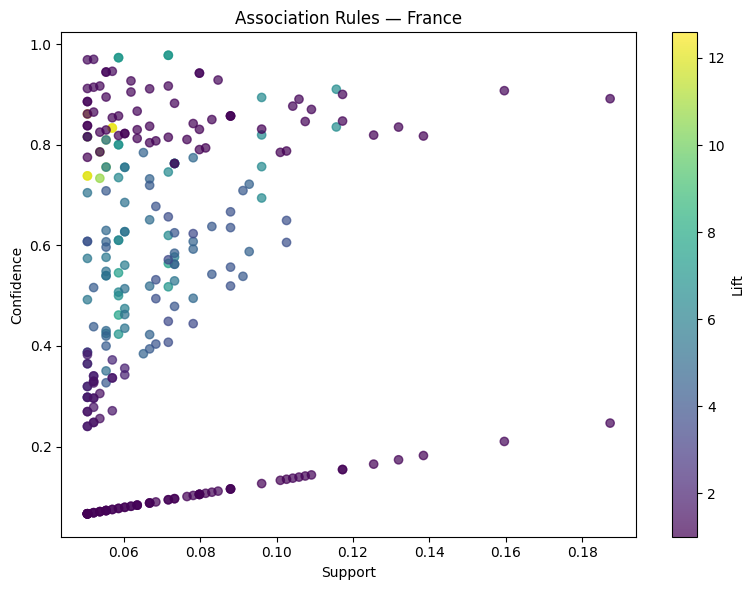

In [13]:
plt.figure(figsize=(8, 6))                                              # set plot size
scatter = plt.scatter(rules_fr['support'], rules_fr['confidence'],        # support vs confidence
                       c=rules_fr['lift'], cmap='viridis', alpha=0.7)      # color points by lift strength
plt.colorbar(scatter, label='Lift')                                       # add a colorbar legend for lift
plt.xlabel('Support')                                                     # x-axis label
plt.ylabel('Confidence')                                                  # y-axis label
plt.title('Association Rules — France')                                  # chart title
plt.tight_layout()                                                        # avoid clipped labels
plt.show()                                                                # display the plot


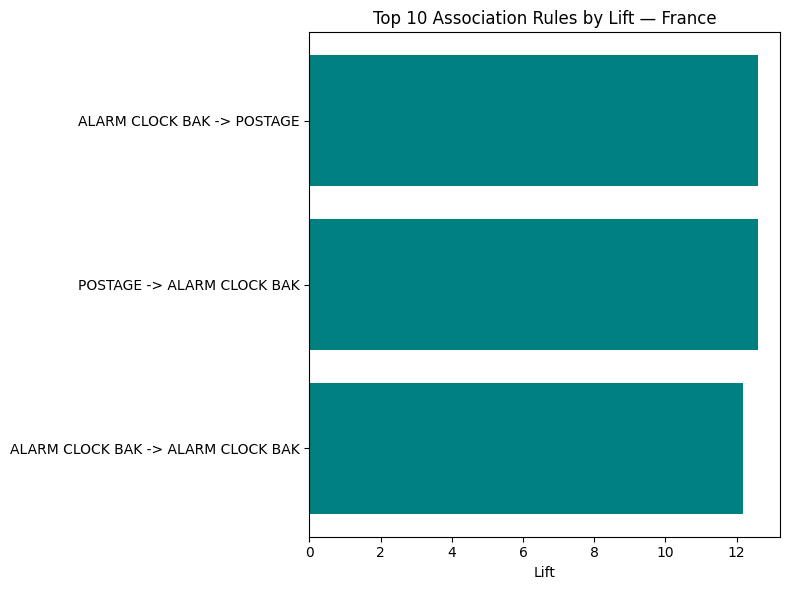

In [14]:
top10_fr = rules_fr.sort_values('lift', ascending=False).head(10)        # top 10 rules by lift
labels = [f"{list(a)[0][:15]} -> {list(c)[0][:15]}"                       # short label per rule for the chart
          for a, c in zip(top10_fr['antecedents'], top10_fr['consequents'])]
plt.figure(figsize=(8, 6))                                                # set plot size
plt.barh(labels, top10_fr['lift'], color='teal')                          # horizontal bar chart of lift
plt.xlabel('Lift')                                                        # x-axis label
plt.title('Top 10 Association Rules by Lift — France')                   # chart title
plt.gca().invert_yaxis()                                                  # highest lift on top
plt.tight_layout()                                                        # avoid clipped labels
plt.show()                                                                # display the plot


## 6. Repeat for the United Kingdom
The UK has far more invoices and products, so we raise `min_support` to keep the itemset search fast and focus on genuinely common combinations.

In [15]:
basket_uk = build_basket(df, 'United Kingdom')          # build the UK basket matrix
basket_uk.shape                                          # (num invoices, num unique products) - much bigger than France


(33541, 5207)

In [16]:
frequent_itemsets_uk = apriori(basket_uk, min_support=0.02, use_colnames=True, low_memory=True)  # higher volume needs a higher support cutoff + low_memory mode
frequent_itemsets_uk = frequent_itemsets_uk.sort_values('support', ascending=False)  # most common itemsets first
frequent_itemsets_uk.head(10)  # preview top itemsets


,support,itemsets
156,0.140157,frozenset({WHITE HANGING HEART T-LIGHT HOLDER})
127,0.085150,frozenset({REGENCY CAKESTAND 3 TIER})
9,0.074655,frozenset({ASSORTED COLOUR BIRD ORNAMENT})
66,0.071286,frozenset({JUMBO BAG RED RETROSPOT})
107,0.057869,frozenset({PARTY BUNTING})
79,0.056707,frozenset({LUNCH BAG BLACK SKULL.})
130,0.054948,frozenset({REX CASH+CARRY JUMBO SHOPPER})
53,0.052712,frozenset({HOME BUILDING BLOCK WORD})
52,0.051579,frozenset({HEART OF WICKER SMALL})
51,0.051310,frozenset({HEART OF WICKER LARGE})


In [17]:
rules_uk = association_rules(frequent_itemsets_uk, metric='lift', min_threshold=1)  # build rules with lift > 1
rules_uk = rules_uk.sort_values('lift', ascending=False)                             # strongest associations first
rules_uk[['antecedents', 'consequents', 'support', 'confidence', 'lift']].head(10)    # show the key columns


,antecedents,consequents,support,confidence,lift
9,frozenset({SWEETHEART CERAMIC TRINKET BOX}),frozenset({STRAWBERRY CERAMIC TRINKET BOX}),0.022540,0.689152,13.949822
8,frozenset({STRAWBERRY CERAMIC TRINKET BOX}),frozenset({SWEETHEART CERAMIC TRINKET BOX}),0.022540,0.456246,13.949822
2,frozenset({WOODEN FRAME ANTIQUE WHITE}),frozenset({WOODEN PICTURE FRAME WHITE FINISH}),0.028979,0.565445,11.772558
3,frozenset({WOODEN PICTURE FRAME WHITE FINISH}),frozenset({WOODEN FRAME ANTIQUE WHITE}),0.028979,0.603352,11.772558
6,frozenset({LOVE BUILDING BLOCK WORD}),frozenset({HOME BUILDING BLOCK WORD}),0.022778,0.528354,10.023487
7,frozenset({HOME BUILDING BLOCK WORD}),frozenset({LOVE BUILDING BLOCK WORD}),0.022778,0.432127,10.023487
5,frozenset({HEART OF WICKER LARGE}),frozenset({HEART OF WICKER SMALL}),0.025491,0.496804,9.631971
4,frozenset({HEART OF WICKER SMALL}),frozenset({HEART OF WICKER LARGE}),0.025491,0.494220,9.631971
10,frozenset({LUNCH BAG SPACEBOY DESIGN}),frozenset({LUNCH BAG BLACK SKULL.}),0.021794,0.435378,7.677718
11,frozenset({LUNCH BAG BLACK SKULL.}),frozenset({LUNCH BAG SPACEBOY DESIGN}),0.021794,0.384332,7.677718


## 7. Takeaways
- Apriori found product pairs/sets that repeatedly co-occur in the same invoice, ranked by **lift** (strength of association) and **confidence** (reliability of the rule).
- These rules are directly usable for: "frequently bought together" recommendations, store/website product placement, and bundle or discount design.
- Next steps: try different `min_support`/`min_threshold` values, test other countries, or feed the top rules into a recommendation widget.